## Building my first agent with langgraph

### Building a wheather chatbot agent that can give the information about wheather of any city.

In [ ]:
#first will define the tools and model and then write langgarph logic code
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from typing import Dict, Any

ImportError: cannot import name 'ModelProfile' from 'langchain_core.language_models' (/home/aayushi/Documents/codes/llm/langraph_learning/.venv/lib/python3.12/site-packages/langchain_core/language_models/__init__.py)

In [3]:
from dotenv import load_dotenv
load_dotenv()

True

#### Define Tools and Model

In [27]:
@tool
def get_weather_information(city:str) -> Dict[str, Any]:
    """This tool gives the information about the wheather of any city"""

    return {"city":city, "temperature":32, "humidity":"54%"}

llm = init_chat_model('groq:llama-3.3-70b-versatile')
tools = [get_weather_information]
llm_with_tools = llm.bind_tools(tools)
tools_with_names = {tool.name:tool for tool in tools}

In [4]:
from langchain_tavily import TavilySearch

In [12]:
get_weather_information = TavilySearch(max_result=2)

llm = init_chat_model('groq:llama-3.3-70b-versatile')
tools = [get_weather_information]
llm_with_tools = llm.bind_tools(tools)
tools_with_names = {tool.name:tool for tool in tools}

#### Define State

In [13]:
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict, Annotated, Literal
from langchain.messages import AnyMessage, SystemMessage, ToolMessage

In [14]:
class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

#### Define the nodes

In [18]:
def llm_chat(state:State):
    return {
        "messages":[llm_with_tools.invoke([
            SystemMessage(content="You are a helpfull agent.Help the user with there queries")
        ]
        + state['messages'])]
    }

def weather_info_tool(state:State):
    last_messages = state["messages"][-1]

    tool_message =[]
    for tool in last_messages.tool_calls:
        the_tool = tools_with_names[tool["name"]]
        tool_calling = the_tool.invoke(tool["args"])
        tool_message.append(ToolMessage(content=tool_calling, tool_call_id=tool["id"]))
    return {"messages":tool_message}

def should_continue(state:State) -> Literal["weather_info_tool", END]:
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "weather_info_tool"
    return END

#### Build StateGraph and compile

In [19]:
graph_builder = StateGraph(State)

graph_builder.add_node("llm_chat", llm_chat)
graph_builder.add_node("weather_info_tool", weather_info_tool)

graph_builder.add_edge(START, "llm_chat")
graph_builder.add_conditional_edges("llm_chat", should_continue, ["weather_info_tool",END])
graph_builder.add_edge("weather_info_tool", "llm_chat")

graph = graph_builder.compile()

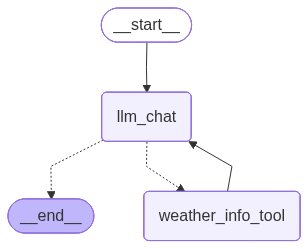

In [20]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
from langchain.messages import HumanMessage
messages = [HumanMessage(content="what is the weather of patna")]
messages = graph.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the weather of patna
================================== Ai Message ==================================
Tool Calls:
  tavily_search (x3ybq93bh)
 Call ID: x3ybq93bh
  Args:
    query: Patna weather
    topic: general
================================= Tool Message =================================

{'query': 'Patna weather', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'title': 'Weather in Patna', 'url': 'https://www.weatherapi.com/', 'content': "{'location': {'name': 'Patna', 'region': 'Bihar', 'country': 'India', 'lat': 25.6, 'lon': 85.1167, 'tz_id': 'Asia/Kolkata', 'localtime_epoch': 1763039899, 'localtime': '2025-11-13 18:48'}, 'current': {'last_updated_epoch': 1763039700, 'last_updated': '2025-11-13 18:45', 'temp_c': 20.0, 'temp_f': 68.0, 'is_day': 0, 'condition': {'text': 'Mist', 'icon': '//cdn.weatherapi.com/weather/64x64/night/143.png', 'code': 1030}, 'wind_mph': 6.3